In [1]:
import sys
from pathlib import Path

# Add the parent directory to the system path
sys.path.append(str(Path.cwd().parent.resolve()))

In [2]:
# Load Libraries
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn import metrics
from datetime import datetime
from matplotlib import pyplot as plt
from prettytable import PrettyTable

In [3]:
# Data Path
path = str(Path.cwd().parent.resolve())
dma_path = path + "/data/DMA_X.csv"

In [4]:
# Load Data
dma_flow = pd.read_csv(dma_path, index_col="TimeStamp", date_format="%d/%m/%Y %H:%M")
dma_flow["Flow"] = dma_flow["Flow"].ewm(alpha=0.75, adjust=False).mean()

# Preview Data
print(dma_flow.head())

# Plot Data
px.line(dma_flow, x=dma_flow.index, y=["Flow"])

                          Flow
TimeStamp                     
2022-04-02 00:00:00  18.713125
2022-04-02 00:05:00  18.488336
2022-04-02 00:10:00  15.147979
2022-04-02 00:15:00  14.835788
2022-04-02 00:20:00  16.903863


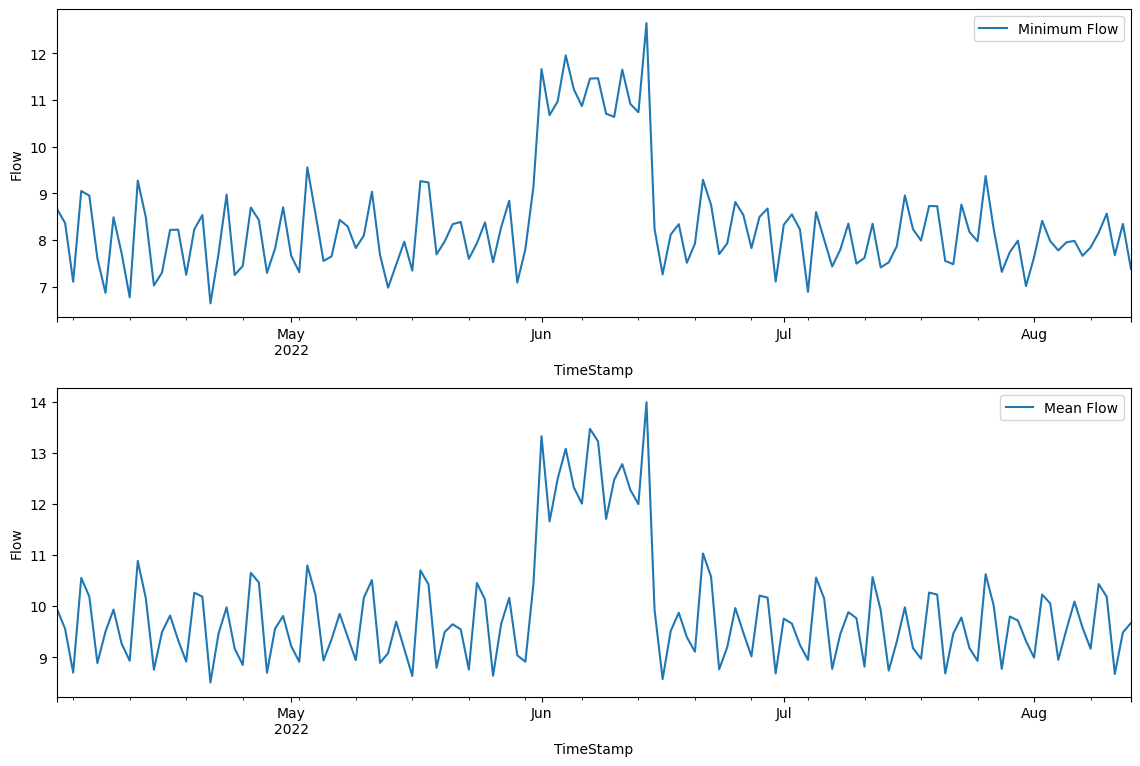

In [5]:
# Daily Night Flows
daily_nightflow = dma_flow.between_time("02:00:00", "03:59:59")
minimum_daily_nightflow = daily_nightflow.resample("1D").min()
average_daily_nightflow = daily_nightflow.resample("1D").mean()

# Visualise NightFlows
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
fig.tight_layout(pad=3.0)

minimum_daily_nightflow["Flow"].plot(ax=ax[0], label="Minimum Flow")
ax[0].set_ylabel("Flow")
ax[0].legend(loc=0)

average_daily_nightflow["Flow"].plot(ax=ax[1], label="Mean Flow")
ax[1].set_ylabel("Flow")
ax[1].legend(loc=0)

plt.show()

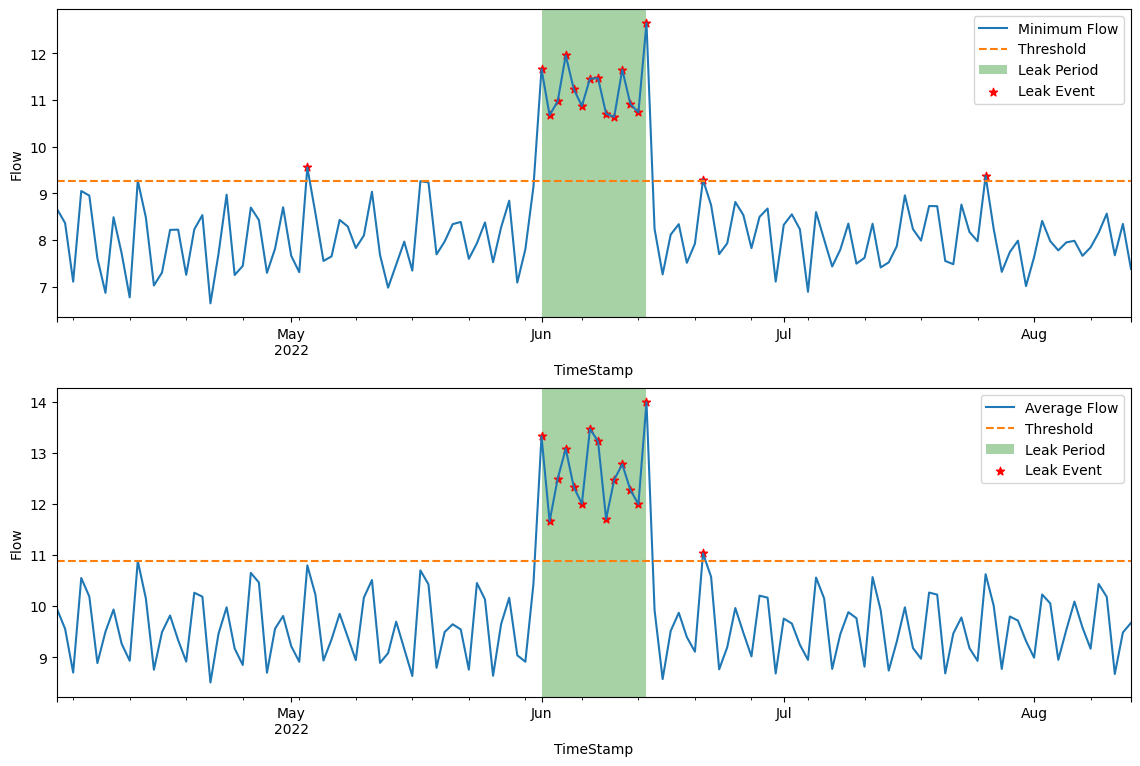

In [6]:
# Compute Night Flow Non-Leak Thresholds
mnf_threshold = minimum_daily_nightflow.loc["2022-04-02 00:00:00":"2022-04-30 23:55:00"].max()
anf_threshold = average_daily_nightflow.loc["2022-04-02 00:00:00":"2022-04-30 23:55:00"].max()

# Idenity Leak events
mnf_leak_idx = minimum_daily_nightflow["Flow"] > mnf_threshold.values[0]
anf_leak_idx = average_daily_nightflow["Flow"] > anf_threshold.values[0]

# Ground Truth on Leakages
leak_starttime = "2022-06-01 00:00:00"
leak_endtime = "2022-06-14 23:55:00"

# Visualize Leaks and Thresholds
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
fig.tight_layout(pad=3.0)
num_days = len(minimum_daily_nightflow)

minimum_daily_nightflow["Flow"].plot(ax=ax[0], label="Minimum Flow")
ax[0].axhline(mnf_threshold.values[0], color="C1", linestyle="--", label="Threshold")
ax[0].axvspan(leak_starttime, leak_endtime, facecolor="green", alpha=0.35, label="Leak Period")
ax[0].scatter(
    minimum_daily_nightflow.index[mnf_leak_idx],
    minimum_daily_nightflow.Flow[mnf_leak_idx],
    marker="*",
    c="r",
    label="Leak Event",
)
ax[0].set_ylabel("Flow")
ax[0].legend(loc=0)

average_daily_nightflow["Flow"].plot(ax=ax[1], label="Average Flow")
ax[1].axhline(anf_threshold.values[0], color="C1", linestyle="--", label="Threshold")
ax[1].axvspan(leak_starttime, leak_endtime, facecolor="green", alpha=0.35, label="Leak Period")
ax[1].scatter(
    average_daily_nightflow.index[anf_leak_idx],
    average_daily_nightflow.Flow[anf_leak_idx],
    marker="*",
    c="r",
    label="Leak Event",
)
ax[1].set_ylabel("Flow")
ax[1].legend(loc=0)

plt.show()

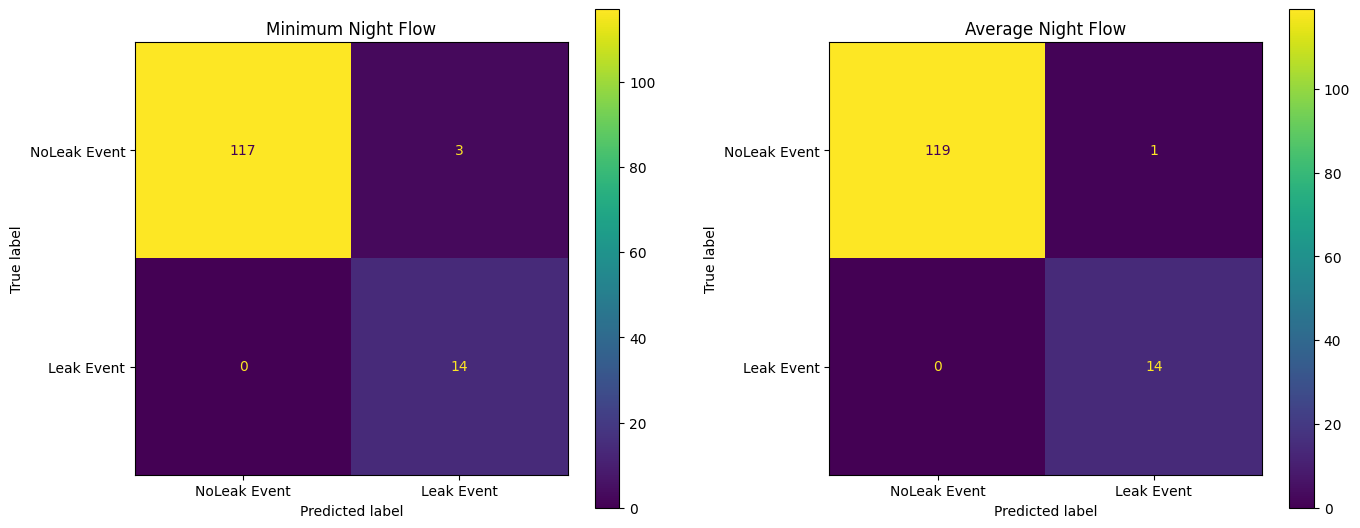

In [7]:
# Leak Ground Turth labels
leak_results = pd.DataFrame()
leak_results.index = minimum_daily_nightflow.index
leak_results["Truth"] = np.zeros((num_days), dtype=int)
leak_results.loc[leak_starttime:leak_endtime, "Truth"] = int(1)
class_labels = ["NoLeak Event", "Leak Event"]

# MNF Predicted Labels
leak_results["MNF Predicted"] = np.zeros((num_days), dtype=int)
leak_results.loc[mnf_leak_idx, "MNF Predicted"] = int(1)
mnf_cm = metrics.confusion_matrix(
    leak_results["Truth"].values, leak_results["MNF Predicted"].values
)
mnf_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=mnf_cm, display_labels=class_labels)

# ANF Predicted Labels
leak_results["ANF Predicted"] = np.zeros((num_days), dtype=int)
leak_results.loc[anf_leak_idx, "ANF Predicted"] = int(1)
anf_cm = metrics.confusion_matrix(
    leak_results["Truth"].values, leak_results["ANF Predicted"].values
)
anf_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=anf_cm, display_labels=class_labels)

# Visualize Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
fig.tight_layout(pad=8.0)

mnf_cm_plot.plot(ax=ax[0])
anf_cm_plot.plot(ax=ax[1])
ax[0].set_title("Minimum Night Flow")
ax[1].set_title("Average Night Flow")

plt.show()

In [8]:
# MNF Performance Scores
mnf_recall = metrics.recall_score(
    leak_results["Truth"].values, leak_results["MNF Predicted"].values
)
mnf_precision = metrics.precision_score(
    leak_results["Truth"].values, leak_results["MNF Predicted"].values
)
mnf_fbeta_score = metrics.fbeta_score(
    leak_results["Truth"].values, leak_results["MNF Predicted"].values, beta=1 / 3
)

# ANF Performance Scores
anf_recall = metrics.recall_score(
    leak_results["Truth"].values, leak_results["ANF Predicted"].values
)
anf_precision = metrics.precision_score(
    leak_results["Truth"].values, leak_results["ANF Predicted"].values
)
anf_fbeta_score = metrics.fbeta_score(
    leak_results["Truth"].values, leak_results["ANF Predicted"].values, beta=1 / 3
)

# Set of Identified Leak Days
true_leakset = set(leak_results.loc[leak_starttime:leak_endtime].index.values.tolist())
mnf_leakset = set(leak_results.loc[mnf_leak_idx].index.values.tolist())
anf_leakset = set(leak_results.loc[anf_leak_idx].index.values.tolist())

# Earlist Leak Identification Time (IT)
true_it = min(true_leakset)
mnf_it = min(true_leakset & mnf_leakset)
anf_it = min(true_leakset & anf_leakset)

# Identification Lag Time
mnf_lagtime = (mnf_it - true_it).days
anf_lagtime = (anf_it - true_it).days

# Print Table of Scores
table_entries = [
    ["Recall", np.round(mnf_recall, 2), np.round(anf_recall, 2)],
    ["Precision", np.round(mnf_precision, 2), np.round(anf_precision, 2)],
    ["FScore(1/3)", np.round(mnf_fbeta_score, 2), np.round(anf_fbeta_score, 2)],
    ["Lag Time", str(mnf_lagtime) + " days", str(anf_lagtime) + " days"],
]
scores_table = PrettyTable(["", "MNF Analysis", "ANF Analysis"])
scores_table.add_rows(table_entries)
print(scores_table)

+-------------+--------------+--------------+
|             | MNF Analysis | ANF Analysis |
+-------------+--------------+--------------+
|    Recall   |     1.0      |     1.0      |
|  Precision  |     0.82     |     0.93     |
| FScore(1/3) |     0.84     |     0.94     |
|   Lag Time  |    0 days    |    0 days    |
+-------------+--------------+--------------+
